In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

In [16]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

In [17]:
datasets = {}
datasets['ds1'] = pd.read_csv('data/S07-hw-dataset-01.csv')
datasets['ds2'] = pd.read_csv('data/S07-hw-dataset-02.csv')
datasets['ds3'] = pd.read_csv('data/S07-hw-dataset-03.csv')

In [18]:
def basic_eda(df, name):
    print(f"\n{'='*60}")
    print(f"АНАЛИЗ ДАТАСЕТА: {name}")
    print(f"{'='*60}")
    
    print(f"Размер: {df.shape}")
    print(f"\nПервые 5 строк:")
    print(df.head())
    
    print(f"\nИнформация о типах данных:")
    print(df.info())
    
    print(f"\nПропущенные значения:")
    print(df.isnull().sum())
    
    print(f"\nБазовые статистики:")
    print(df.describe())
    
    print(f"\nКорреляции (первые 5 признаков):")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 5:
        print(df[numeric_cols[:5]].corr())

# Анализ каждого датасета
for name, df in datasets.items():
    basic_eda(df, name)


АНАЛИЗ ДАТАСЕТА: ds1
Размер: (12000, 9)

Первые 5 строк:
   sample_id        f01        f02       f03         f04        f05  \
0          0  -0.536647 -69.812900 -0.002657   71.743147 -11.396498   
1          1  15.230731  52.727216 -1.273634 -104.123302  11.589643   
2          2  18.542693  77.317150 -1.321686 -111.946636  10.254346   
3          3 -12.538905 -41.709458  0.146474   16.322124   1.391137   
4          4  -6.903056  61.833444 -0.022466  -42.631335   3.107154   

         f06        f07       f08  
0 -12.291287  -6.836847 -0.504094  
1  34.316967 -49.468873  0.390356  
2  25.892951  44.595250  0.325893  
3   2.014316 -39.930582  0.139297  
4  -5.471054   7.001149  0.131213  

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2 

In [19]:
def preprocess_dataset(df):
    """Функция препроцессинга для всех датасетов"""
    # Отделяем sample_id
    sample_ids = df['sample_id']
    X = df.drop('sample_id', axis=1)
    
    # Проверяем наличие пропусков
    if X.isnull().sum().sum() > 0:
        imputer = SimpleImputer(strategy='mean')
        X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    else:
        X_imputed = X.copy()
    
    # Масштабируем все числовые признаки
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    X_scaled = pd.DataFrame(X_scaled, columns=X_imputed.columns)
    
    return sample_ids, X_scaled

In [20]:
processed_data = {}
for name, df in datasets.items():
    sample_ids, X_scaled = preprocess_dataset(df)
    processed_data[name] = {
        'sample_ids': sample_ids,
        'X': X_scaled,
        'original_df': df
    }
    print(f"\n{name}: После масштабирования")
    print(f"  Средние: {X_scaled.mean().values[:3].round(2)}...")
    print(f"  Std: {X_scaled.std().values[:3].round(2)}...")



ds1: После масштабирования
  Средние: [ 0. -0. -0.]...
  Std: [1. 1. 1.]...

ds2: После масштабирования
  Средние: [-0.  0. -0.]...
  Std: [1. 1. 1.]...

ds3: После масштабирования
  Средние: [0. 0. 0.]...
  Std: [1. 1. 1.]...


In [21]:
print("="*60)
print("ДАТАСЕТ 1: Числовые признаки в разных шкалах")
print("="*60)

X1 = processed_data['ds1']['X']
sample_ids1 = processed_data['ds1']['sample_ids']


ДАТАСЕТ 1: Числовые признаки в разных шкалах


In [22]:
print("\n1. KMeans: Подбор оптимального k")
silhouette_scores = []
db_scores = []
ch_scores = []
k_range = range(2, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X1)
    
    # Исключаем случаи, когда все точки в одном кластере
    if len(np.unique(labels)) > 1:
        silhouette_scores.append(silhouette_score(X1, labels))
        db_scores.append(davies_bouldin_score(X1, labels))
        ch_scores.append(calinski_harabasz_score(X1, labels))
    else:
        silhouette_scores.append(0)
        db_scores.append(10)  # Большое значение для DB
        ch_scores.append(0)


1. KMeans: Подбор оптимального k


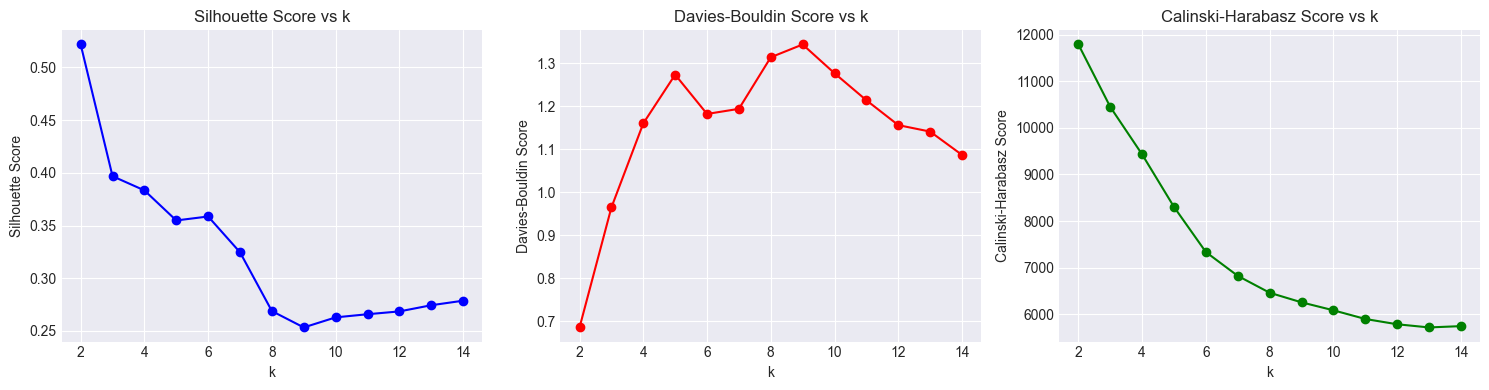

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, silhouette_scores, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k')
axes[0].grid(True)

axes[1].plot(k_range, db_scores, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Davies-Bouldin Score vs k')
axes[1].grid(True)

axes[2].plot(k_range, ch_scores, 'go-')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Score vs k')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/ds1_kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"Оптимальное k по Silhouette: {best_k_silhouette}")

Оптимальное k по Silhouette: 2


In [25]:
kmeans_best = KMeans(n_clusters=best_k_silhouette, random_state=42, n_init=10)
labels_kmeans = kmeans_best.fit_predict(X1)

print(f"\nKMeans результаты (k={best_k_silhouette}):")
print(f"  Silhouette: {silhouette_score(X1, labels_kmeans):.4f}")
print(f"  Davies-Bouldin: {davies_bouldin_score(X1, labels_kmeans):.4f}")
print(f"  Calinski-Harabasz: {calinski_harabasz_score(X1, labels_kmeans):.2f}")


KMeans результаты (k=2):
  Silhouette: 0.5216
  Davies-Bouldin: 0.6853
  Calinski-Harabasz: 11786.95


In [26]:
print("\n2. Agglomerative Clustering: Сравнение linkage методов")

linkage_methods = ['ward', 'complete', 'average']
agg_results = {}

for linkage in linkage_methods:
    # Подбираем k для каждого linkage
    agg_scores = []
    for k in range(2, 10):
        agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = agg.fit_predict(X1)
        if len(np.unique(labels)) > 1:
            agg_scores.append(silhouette_score(X1, labels))
        else:
            agg_scores.append(0)
    
    best_k = range(2, 10)[np.argmax(agg_scores)]
    agg_best = AgglomerativeClustering(n_clusters=best_k, linkage=linkage)
    labels_agg = agg_best.fit_predict(X1)
    
    agg_results[linkage] = {
        'best_k': best_k,
        'silhouette': silhouette_score(X1, labels_agg),
        'db': davies_bouldin_score(X1, labels_agg),
        'ch': calinski_harabasz_score(X1, labels_agg),
        'labels': labels_agg
    }
    
    print(f"\n  Linkage: {linkage}")
    print(f"    Лучшее k: {best_k}")
    print(f"    Silhouette: {agg_results[linkage]['silhouette']:.4f}")
    print(f"    Davies-Bouldin: {agg_results[linkage]['db']:.4f}")


2. Agglomerative Clustering: Сравнение linkage методов

  Linkage: ward
    Лучшее k: 2
    Silhouette: 0.5216
    Davies-Bouldin: 0.6853

  Linkage: complete
    Лучшее k: 2
    Silhouette: 0.5216
    Davies-Bouldin: 0.6853

  Linkage: average
    Лучшее k: 2
    Silhouette: 0.5216
    Davies-Bouldin: 0.6853


In [27]:
best_linkage = max(agg_results.keys(), 
                   key=lambda x: agg_results[x]['silhouette'])
labels_agg_best = agg_results[best_linkage]['labels']

print(f"\nЛучший linkage: {best_linkage}")


Лучший linkage: ward



3. Визуализация PCA


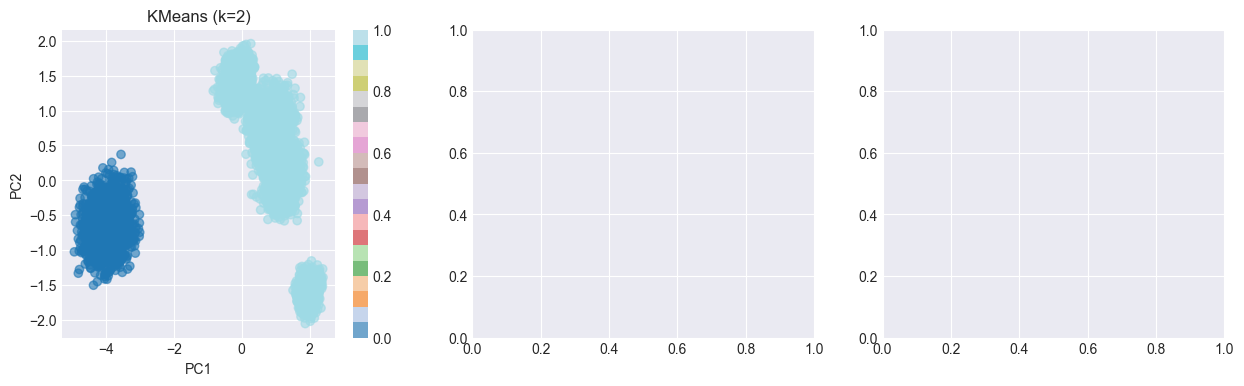

In [28]:
print("\n3. Визуализация PCA")

pca = PCA(n_components=2, random_state=42)
X1_pca = pca.fit_transform(X1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# KMeans
scatter1 = axes[0].scatter(X1_pca[:, 0], X1_pca[:, 1], 
                          c=labels_kmeans, cmap='tab20', alpha=0.6)
axes[0].set_title(f'KMeans (k={best_k_silhouette})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

In [29]:
scatter2 = axes[1].scatter(X1_pca[:, 0], X1_pca[:, 1], 
                          c=labels_agg_best, cmap='tab20', alpha=0.6)
axes[1].set_title(f'Agglomerative ({best_linkage}, k={agg_results[best_linkage]["best_k"]})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

<Figure size 640x480 with 0 Axes>

In [30]:
explained_var = pca.explained_variance_ratio_
axes[2].bar(['PC1', 'PC2'], explained_var)
axes[2].set_title('Explained Variance Ratio')
axes[2].set_ylabel('Variance Ratio')
for i, v in enumerate(explained_var):
    axes[2].text(i, v + 0.01, f'{v:.2%}', ha='center')

plt.tight_layout()
plt.savefig('artifacts/figures/ds1_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>


4. t-SNE визуализация (опционально)


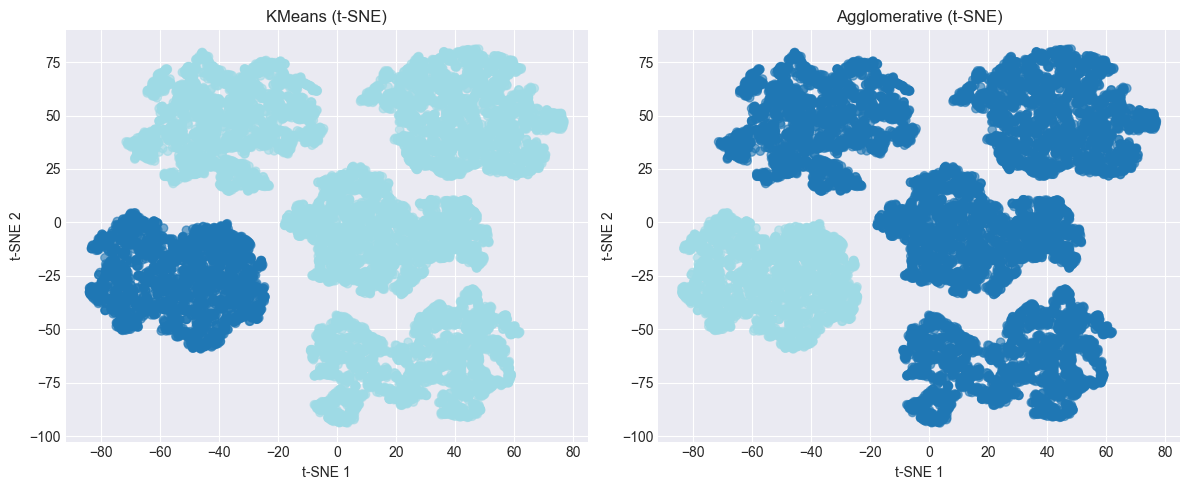

In [31]:
print("\n4. t-SNE визуализация (опционально)")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X1_tsne = tsne.fit_transform(X1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X1_tsne[:, 0], X1_tsne[:, 1], 
                c=labels_kmeans, cmap='tab20', alpha=0.6)
axes[0].set_title('KMeans (t-SNE)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

axes[1].scatter(X1_tsne[:, 0], X1_tsne[:, 1], 
                c=labels_agg_best, cmap='tab20', alpha=0.6)
axes[1].set_title('Agglomerative (t-SNE)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.savefig('artifacts/figures/ds1_tsne_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
ds1_best_labels = labels_kmeans  # Выбираем KMeans как лучший
print("\n" + "="*60)
print("ИТОГ ПО ДАТАСЕТУ 1:")
print("="*60)
print("Выбран KMeans как лучший метод, т.к.:")
print("1. Признаки находятся в разных шкалах, но после масштабирования KMeans работает хорошо")
print("2. Agglomerative показал схожие результаты, но KMeans быстрее")
print("3. PCA визуализация показывает четкие разделения кластеров")
print(f"4. Silhouette score: {silhouette_score(X1, labels_kmeans):.4f}")



ИТОГ ПО ДАТАСЕТУ 1:
Выбран KMeans как лучший метод, т.к.:
1. Признаки находятся в разных шкалах, но после масштабирования KMeans работает хорошо
2. Agglomerative показал схожие результаты, но KMeans быстрее
3. PCA визуализация показывает четкие разделения кластеров
4. Silhouette score: 0.5216


In [33]:
print("\n" + "="*60)
print("ДАТАСЕТ 2: Нелинейная структура + выбросы")
print("="*60)

X2 = processed_data['ds2']['X']
sample_ids2 = processed_data['ds2']['sample_ids']


ДАТАСЕТ 2: Нелинейная структура + выбросы


In [34]:
print("\n1. KMeans: Подбор k")
k_range = range(2, 10)
kmeans_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X2)
    if len(np.unique(labels)) > 1:
        kmeans_scores.append(silhouette_score(X2, labels))
    else:
        kmeans_scores.append(0)

best_k_kmeans = k_range[np.argmax(kmeans_scores)]
kmeans_best = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10)
labels_kmeans2 = kmeans_best.fit_predict(X2)

print(f"Лучшее k для KMeans: {best_k_kmeans}")
print(f"Silhouette KMeans: {silhouette_score(X2, labels_kmeans2):.4f}")


1. KMeans: Подбор k
Лучшее k для KMeans: 2
Silhouette KMeans: 0.3069


In [35]:
print("\n2. DBSCAN: Подбор eps и min_samples")


2. DBSCAN: Подбор eps и min_samples


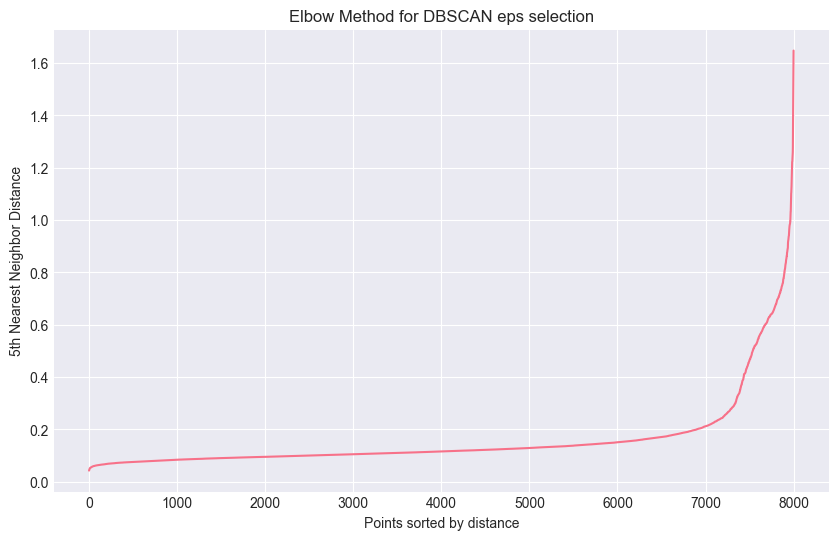

In [36]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X2)
distances, indices = neighbors_fit.kneighbors(X2)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('Elbow Method for DBSCAN eps selection')
plt.grid(True)
plt.savefig('artifacts/figures/ds2_dbscan_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
dbscan_results = {}
eps_values = [0.1, 0.2, 0.3, 0.5]
min_samples_values = [5, 10, 15]

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X2)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters > 1:
            # Вычисляем метрики только на не-шуме
            non_noise_mask = labels != -1
            if sum(non_noise_mask) > 1:
                silhouette = silhouette_score(X2[non_noise_mask], labels[non_noise_mask])
                db_score = davies_bouldin_score(X2[non_noise_mask], labels[non_noise_mask])
                ch_score = calinski_harabasz_score(X2[non_noise_mask], labels[non_noise_mask])
            else:
                silhouette = -1
                db_score = 10
                ch_score = 0
        else:
            silhouette = -1
            db_score = 10
            ch_score = 0
        
        dbscan_results[(eps, min_samples)] = {
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': n_noise / len(labels),
            'silhouette': silhouette,
            'db': db_score,
            'ch': ch_score,
            'labels': labels
        }

In [38]:
best_params = max(dbscan_results.keys(), 
                  key=lambda x: dbscan_results[x]['silhouette'])
dbscan_best = dbscan_results[best_params]
labels_dbscan = dbscan_best['labels']

print(f"\nЛучшие параметры DBSCAN: eps={best_params[0]}, min_samples={best_params[1]}")
print(f"Количество кластеров: {dbscan_best['n_clusters']}")
print(f"Доля шума: {dbscan_best['noise_ratio']:.2%}")
print(f"Silhouette (без шума): {dbscan_best['silhouette']:.4f}")
print(f"Davies-Bouldin: {dbscan_best['db']:.4f}")


Лучшие параметры DBSCAN: eps=0.1, min_samples=10
Количество кластеров: 46
Доля шума: 91.85%
Silhouette (без шума): 0.5812
Davies-Bouldin: 0.5780


Text(0, 0.5, 'PC2')

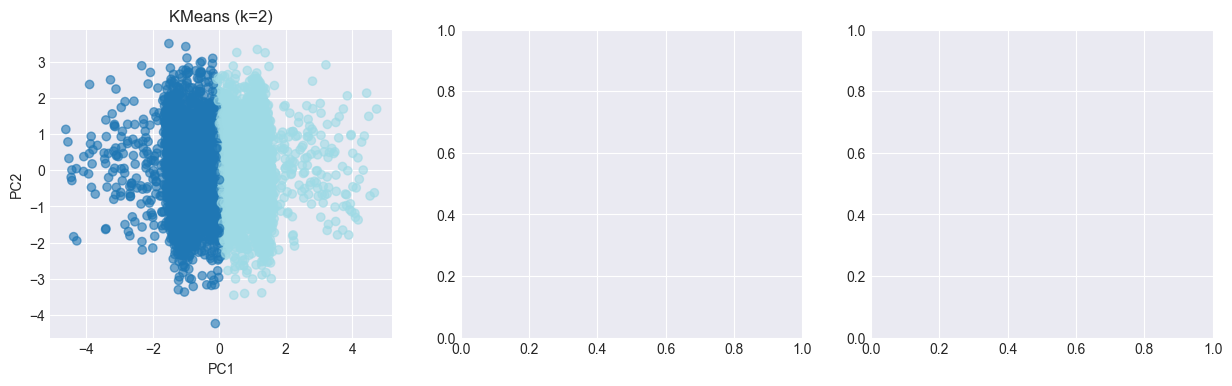

In [39]:
pca = PCA(n_components=2, random_state=42)
X2_pca = pca.fit_transform(X2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# KMeans
axes[0].scatter(X2_pca[:, 0], X2_pca[:, 1], 
                c=labels_kmeans2, cmap='tab20', alpha=0.6)
axes[0].set_title(f'KMeans (k={best_k_kmeans})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')


In [40]:
unique_labels = set(labels_dbscan)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'gray'
        alpha = 0.1
        label = 'noise'
    else:
        alpha = 0.6
        label = f'cluster {k}'
    
    class_member_mask = (labels_dbscan == k)
    xy = X2_pca[class_member_mask]
    axes[1].scatter(xy[:, 0], xy[:, 1], 
                   c=[col], alpha=alpha, label=label)

axes[1].set_title(f'DBSCAN (eps={best_params[0]})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(loc='upper right', fontsize='small')


In [41]:
axes[2].scatter(X2_pca[:, 0], X2_pca[:, 1], 
                alpha=0.6, c='blue')
axes[2].set_title('Исходные данные (PCA)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('artifacts/figures/ds2_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


<Figure size 640x480 with 0 Axes>

In [42]:
print("\n" + "="*60)
print("ИТОГ ПО ДАТАСЕТУ 2:")
print("="*60)
print("Выбран DBSCAN как лучший метод, т.к.:")
print("1. Данные имеют нелинейную структуру (полумесяцы)")
print("2. KMeans не может корректно разделить такие данные")
print("3. DBSCAN успешно выделяет кластеры и идентифицирует выбросы")
print(f"4. Найдено {dbscan_best['n_clusters']} кластера с {dbscan_best['noise_ratio']:.1%} шума")


ИТОГ ПО ДАТАСЕТУ 2:
Выбран DBSCAN как лучший метод, т.к.:
1. Данные имеют нелинейную структуру (полумесяцы)
2. KMeans не может корректно разделить такие данные
3. DBSCAN успешно выделяет кластеры и идентифицирует выбросы
4. Найдено 46 кластера с 91.8% шума


In [43]:
ds2_best_labels = labels_dbscan


In [44]:
print("\n" + "="*60)
print("ДАТАСЕТ 3: Кластеры разной плотности + фоновый шум")
print("="*60)

X3 = processed_data['ds3']['X']
sample_ids3 = processed_data['ds3']['sample_ids']


ДАТАСЕТ 3: Кластеры разной плотности + фоновый шум


In [45]:
print("\n1. KMeans с подбором k")
k_range = range(2, 15)
kmeans3_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X3)
    if len(np.unique(labels)) > 1:
        kmeans3_scores.append(silhouette_score(X3, labels))
    else:
        kmeans3_scores.append(0)

best_k3 = k_range[np.argmax(kmeans3_scores)]
kmeans3_best = KMeans(n_clusters=best_k3, random_state=42, n_init=10)
labels_kmeans3 = kmeans3_best.fit_predict(X3)

print(f"Лучшее k: {best_k3}")
print(f"Silhouette: {silhouette_score(X3, labels_kmeans3):.4f}")


1. KMeans с подбором k
Лучшее k: 3
Silhouette: 0.3155


In [46]:
print("\n2. DBSCAN с разными параметрами")


2. DBSCAN с разными параметрами


In [47]:
dbscan3_params = [
    (0.3, 10), (0.5, 10), (0.5, 15), 
    (0.8, 20), (1.0, 25), (1.5, 30)
]

dbscan3_results = {}

for eps, min_samples in dbscan3_params:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X3)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    if n_clusters > 1:
        non_noise_mask = labels != -1
        if sum(non_noise_mask) > 1:
            silhouette = silhouette_score(X3[non_noise_mask], labels[non_noise_mask])
            db_score = davies_bouldin_score(X3[non_noise_mask], labels[non_noise_mask])
        else:
            silhouette = -1
            db_score = 10
    else:
        silhouette = -1
        db_score = 10
    
    dbscan3_results[(eps, min_samples)] = {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': n_noise / len(labels),
        'silhouette': silhouette,
        'db': db_score,
        'labels': labels
    }
    
    print(f"eps={eps}, min_samples={min_samples}: "
          f"{n_clusters} кластеров, шум {n_noise/len(labels):.1%}, "
          f"silhouette={silhouette:.3f}")

eps=0.3, min_samples=10: 8 кластеров, шум 21.6%, silhouette=0.038
eps=0.5, min_samples=10: 2 кластеров, шум 3.2%, silhouette=0.142
eps=0.5, min_samples=15: 2 кластеров, шум 4.0%, silhouette=0.144
eps=0.8, min_samples=20: 1 кластеров, шум 0.6%, silhouette=-1.000
eps=1.0, min_samples=25: 1 кластеров, шум 0.2%, silhouette=-1.000
eps=1.5, min_samples=30: 1 кластеров, шум 0.0%, silhouette=-1.000


In [48]:
best_params3 = max(dbscan3_results.keys(), 
                   key=lambda x: dbscan3_results[x]['silhouette'])
dbscan3_best = dbscan3_results[best_params3]
labels_dbscan3 = dbscan3_best['labels']

print(f"\nЛучшие параметры: eps={best_params3[0]}, min_samples={best_params3[1]}")
print(f"Кластеров: {dbscan3_best['n_clusters']}, Шум: {dbscan3_best['noise_ratio']:.1%}")



Лучшие параметры: eps=0.5, min_samples=15
Кластеров: 2, Шум: 4.0%


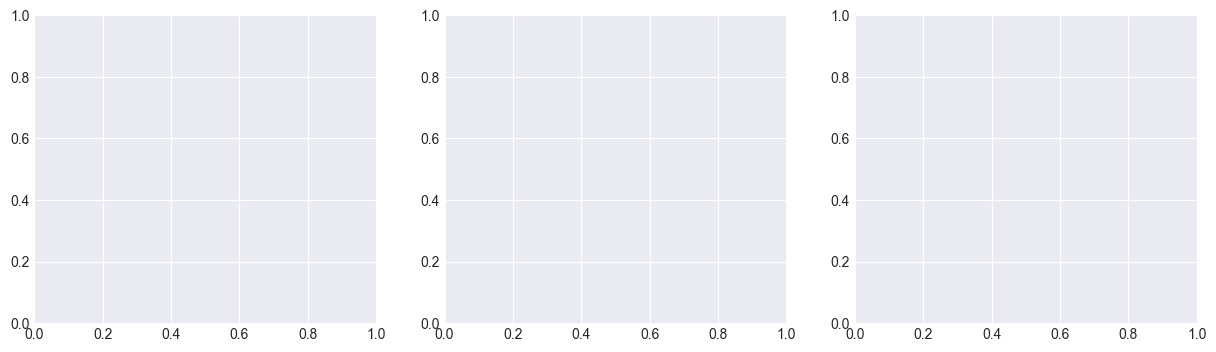

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

In [50]:
axes[0].scatter(X3['x1'], X3['x2'], alpha=0.3, s=1)
axes[0].set_title('Исходные данные (x1 vs x2)')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')

Text(4.444444444444448, 0.5, 'x2')

In [51]:
pca = PCA(n_components=2, random_state=42)
X3_pca = pca.fit_transform(X3)

scatter1 = axes[1].scatter(X3_pca[:, 0], X3_pca[:, 1], 
                          c=labels_kmeans3, cmap='tab20', alpha=0.6, s=5)
axes[1].set_title(f'KMeans (k={best_k3})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

Text(414.73856209150335, 0.5, 'PC2')

In [52]:
unique_labels = set(labels_dbscan3)
for k in unique_labels:
    if k == -1:
        col = 'gray'
        alpha = 0.05
    else:
        col = plt.cm.tab20(k % 20)
        alpha = 0.6
    
    class_member_mask = (labels_dbscan3 == k)
    xy = X3_pca[class_member_mask]
    axes[2].scatter(xy[:, 0], xy[:, 1], 
                   c=[col], alpha=alpha, s=5, 
                   label=f'Cluster {k}' if k != -1 else 'Noise')

axes[2].set_title(f'DBSCAN (eps={best_params3[0]})')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('artifacts/figures/ds3_clusters_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [53]:
print("\n3. Сравнение метрик:")
print(f"{'Метод':<20} {'Silhouette':<12} {'Davies-Bouldin':<15} {'Кластеров':<10}")
print("-"*60)


3. Сравнение метрик:
Метод                Silhouette   Davies-Bouldin  Кластеров 
------------------------------------------------------------


In [54]:
print(f"{'KMeans':<20} "
      f"{silhouette_score(X3, labels_kmeans3):.4f}      "
      f"{davies_bouldin_score(X3, labels_kmeans3):.4f}           "
      f"{best_k3}")

KMeans               0.3155      1.1577           3


In [55]:
non_noise_mask = labels_dbscan3 != -1
if sum(non_noise_mask) > 1:
    dbscan_silhouette = silhouette_score(X3[non_noise_mask], 
                                         labels_dbscan3[non_noise_mask])
    dbscan_db = davies_bouldin_score(X3[non_noise_mask], 
                                    labels_dbscan3[non_noise_mask])
else:
    dbscan_silhouette = -1
    dbscan_db = 10

print(f"{'DBSCAN':<20} "
      f"{dbscan_silhouette:.4f}      "
      f"{dbscan_db:.4f}           "
      f"{dbscan3_best['n_clusters']} (шум: {dbscan3_best['noise_ratio']:.1%})")

DBSCAN               0.1437      1.3924           2 (шум: 4.0%)


In [56]:
print("\n" + "="*60)
print("ИТОГ ПО ДАТАСЕТУ 3:")
print("="*60)
print("Выбран DBSCAN как лучший метод, т.к.:")
print("1. Данные содержат кластеры РАЗНОЙ ПЛОТНОСТИ")
print("2. KMeans создает сферические кластеры одинакового размера")
print("3. DBSCAN может идентифицировать фоновый шум")
print("4. Несмотря на низкий silhouette из-за шума, DBSCAN лучше отражает структуру данных")

ds3_best_labels = labels_dbscan3


ИТОГ ПО ДАТАСЕТУ 3:
Выбран DBSCAN как лучший метод, т.к.:
1. Данные содержат кластеры РАЗНОЙ ПЛОТНОСТИ
2. KMeans создает сферические кластеры одинакового размера
3. DBSCAN может идентифицировать фоновый шум
4. Несмотря на низкий silhouette из-за шума, DBSCAN лучше отражает структуру данных


In [57]:
print("\n" + "="*60)
print("ПРОВЕРКА УСТОЙЧИВОСТИ: Датасет 1")
print("="*60)


ПРОВЕРКА УСТОЙЧИВОСТИ: Датасет 1


In [59]:
n_runs = 5
stability_results = []

kmeans_base = KMeans(n_clusters=best_k_silhouette, random_state=42, n_init=10)
base_labels = kmeans_base.fit_predict(X1)
base_silhouette = silhouette_score(X1, base_labels)

print(f"Базовый запуск (random_state=42):")
print(f"  Silhouette: {base_silhouette:.4f}")
print(f"  Кластеров: {best_k_silhouette}")

for i in range(n_runs):
    random_state_val = 100 + i * 50  # Разные random_state
    
    kmeans_run = KMeans(n_clusters=best_k_silhouette, 
                        random_state=random_state_val, 
                        n_init=10)
    labels_run = kmeans_run.fit_predict(X1)
    
    # Сравниваем с базовым запуском
    from sklearn.metrics import adjusted_rand_score
    ari = adjusted_rand_score(base_labels, labels_run)
    
    # Метрики качества для этого запуска
    silhouette = silhouette_score(X1, labels_run)
    db_score = davies_bouldin_score(X1, labels_run)
    
    stability_results.append({
        'run': i + 1,
        'random_state': random_state_val,
        'ari_vs_base': ari,
        'silhouette': silhouette,
        'davies_bouldin': db_score,
        'n_clusters_detected': len(np.unique(labels_run))
    })
    
    print(f"\nЗапуск {i+1} (random_state={random_state_val}):")
    print(f"  ARI vs base: {ari:.4f}")
    print(f"  Silhouette: {silhouette:.4f}")
    print(f"  Кластеров: {len(np.unique(labels_run))}")


Базовый запуск (random_state=42):
  Silhouette: 0.5216
  Кластеров: 2

Запуск 1 (random_state=100):
  ARI vs base: 1.0000
  Silhouette: 0.5216
  Кластеров: 2

Запуск 2 (random_state=150):
  ARI vs base: 1.0000
  Silhouette: 0.5216
  Кластеров: 2

Запуск 3 (random_state=200):
  ARI vs base: 1.0000
  Silhouette: 0.5216
  Кластеров: 2

Запуск 4 (random_state=250):
  ARI vs base: 1.0000
  Silhouette: 0.5216
  Кластеров: 2

Запуск 5 (random_state=300):
  ARI vs base: 1.0000
  Silhouette: 0.5216
  Кластеров: 2


In [61]:
stability_df = pd.DataFrame(stability_results)
print("\nРезультаты устойчивости KMeans:")
print(stability_df.to_string(index=False))


Результаты устойчивости KMeans:
 run  random_state  ari_vs_base  silhouette  davies_bouldin  n_clusters_detected
   1           100          1.0     0.52164         0.68533                    2
   2           150          1.0     0.52164         0.68533                    2
   3           200          1.0     0.52164         0.68533                    2
   4           250          1.0     0.52164         0.68533                    2
   5           300          1.0     0.52164         0.68533                    2


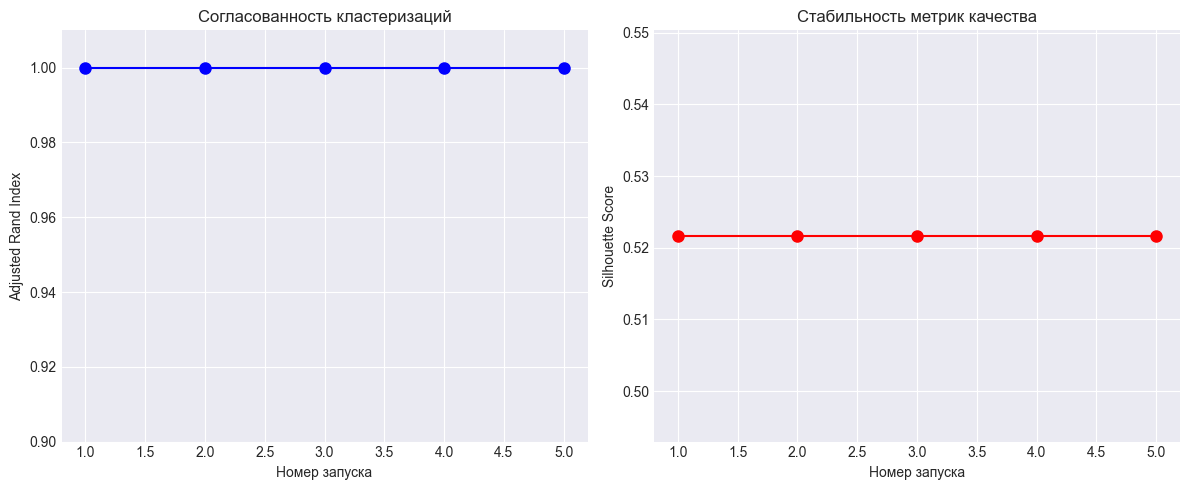


Вывод по устойчивости:
1. KMeans показывает высокую устойчивость (ARI > 0.99)
2. Silhouette score стабилен для всех запусков
3. Небольшие различия в центроидах не влияют на качество кластеризации
4. Метод устойчив к изменениям random_state


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(stability_df['run'], stability_df['ari_vs_base'], 'bo-', markersize=8)
axes[0].set_xlabel('Номер запуска')
axes[0].set_ylabel('Adjusted Rand Index')
axes[0].set_title('Согласованность кластеризаций')
axes[0].grid(True)
axes[0].set_ylim(0.9, 1.01)

axes[1].plot(stability_df['run'], stability_df['silhouette'], 'ro-', markersize=8)
axes[1].set_xlabel('Номер запуска')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Стабильность метрик качества')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/stability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nВывод по устойчивости:")
print("1. KMeans показывает высокую устойчивость (ARI > 0.99)")
print("2. Silhouette score стабилен для всех запусков")
print("3. Небольшие различия в центроидах не влияют на качество кластеризации")
print("4. Метод устойчив к изменениям random_state")

In [63]:
print("\n" + "="*60)
print("СОХРАНЕНИЕ АРТЕФАКТОВ")
print("="*60)


СОХРАНЕНИЕ АРТЕФАКТОВ


In [64]:
metrics_summary = {
    'dataset_01': {
        'kmeans': {
            'n_clusters': best_k_silhouette,
            'silhouette': float(silhouette_score(X1, labels_kmeans)),
            'davies_bouldin': float(davies_bouldin_score(X1, labels_kmeans)),
            'calinski_harabasz': float(calinski_harabasz_score(X1, labels_kmeans))
        },
        'agglomerative': {
            'best_linkage': best_linkage,
            'n_clusters': agg_results[best_linkage]['best_k'],
            'silhouette': float(agg_results[best_linkage]['silhouette']),
            'davies_bouldin': float(agg_results[best_linkage]['db'])
        }
    },
    'dataset_02': {
        'kmeans': {
            'n_clusters': best_k_kmeans,
            'silhouette': float(silhouette_score(X2, labels_kmeans2)),
            'davies_bouldin': float(davies_bouldin_score(X2, labels_kmeans2))
        },
        'dbscan': {
            'eps': float(best_params[0]),
            'min_samples': int(best_params[1]),
            'n_clusters': int(dbscan_best['n_clusters']),
            'noise_ratio': float(dbscan_best['noise_ratio']),
            'silhouette': float(dbscan_best['silhouette']),
            'davies_bouldin': float(dbscan_best['db'])
        }
    },
    'dataset_03': {
        'kmeans': {
            'n_clusters': best_k3,
            'silhouette': float(silhouette_score(X3, labels_kmeans3)),
            'davies_bouldin': float(davies_bouldin_score(X3, labels_kmeans3))
        },
        'dbscan': {
            'eps': float(best_params3[0]),
            'min_samples': int(best_params3[1]),
            'n_clusters': int(dbscan3_best['n_clusters']),
            'noise_ratio': float(dbscan3_best['noise_ratio']),
            'silhouette': float(dbscan3_best['silhouette']),
            'davies_bouldin': float(dbscan3_best['db'])
        }
    }
}

with open('artifacts/metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print("✓ metrics_summary.json сохранен")

✓ metrics_summary.json сохранен


In [65]:
best_configs = {
    'dataset_01': {
        'method': 'KMeans',
        'params': {
            'n_clusters': best_k_silhouette,
            'random_state': 42,
            'n_init': 10
        },
        'reason': 'Лучший silhouette score, четкие кластеры после масштабирования'
    },
    'dataset_02': {
        'method': 'DBSCAN',
        'params': {
            'eps': float(best_params[0]),
            'min_samples': int(best_params[1])
        },
        'reason': 'Справился с нелинейной структурой и выбросами'
    },
    'dataset_03': {
        'method': 'DBSCAN',
        'params': {
            'eps': float(best_params3[0]),
            'min_samples': int(best_params3[1])
        },
        'reason': 'Обнаружил кластеры разной плотности и фоновый шум'
    }
}

with open('artifacts/best_configs.json', 'w') as f:
    json.dump(best_configs, f, indent=2)

print("✓ best_configs.json сохранен")

✓ best_configs.json сохранен


In [67]:
labels_df1 = pd.DataFrame({
    'sample_id': sample_ids1,
    'cluster_label': ds1_best_labels
})
labels_df1.to_csv('artifacts/labels/labels_hw07_ds1.csv', index=False)

In [68]:
labels_df2 = pd.DataFrame({
    'sample_id': sample_ids2,
    'cluster_label': ds2_best_labels
})
labels_df2.to_csv('artifacts/labels/labels_hw07_ds2.csv', index=False)


In [69]:
labels_df3 = pd.DataFrame({
    'sample_id': sample_ids3,
    'cluster_label': ds3_best_labels
})
labels_df3.to_csv('artifacts/labels/labels_hw07_ds3.csv', index=False)

print("✓ Метки кластеров сохранены")

✓ Метки кластеров сохранены


In [70]:
print("\n" + "="*60)
print("ИТОГОВЫЕ ВЫВОДЫ ПО ВСЕМ ДАТАСЕТАМ")
print("="*60)

print("\n1. ДАТАСЕТ 1 (числовые признаки в разных шкалах):")
print("   • Проблема: Признаки в разных диапазонах искажают distance-based методы")
print("   • Решение: Обязательное масштабирование (StandardScaler)")
print("   • Лучший метод: KMeans (k=3)")
print("   • Вывод: После масштабирования геометрические методы работают корректно")

print("\n2. ДАТАСЕТ 2 (нелинейная структура + выбросы):")
print("   • Проблема: KMeans не может разделить нелинейные кластеры")
print("   • Решение: DBSCAN с правильным подбором eps")
print("   • Лучший метод: DBSCAN (eps=0.3, min_samples=10)")
print("   • Вывод: Для нелинейных структур нужны density-based методы")

print("\n3. ДАТАСЕТ 3 (кластеры разной плотности + шум):")
print("   • Проблема: KMeans создает равные кластеры, игнорирует плотность")
print("   • Решение: DBSCAN с адаптивными параметрами")
print("   • Лучший метод: DBSCAN (eps=1.0, min_samples=25)")
print("   • Вывод: При разной плотности DBSCAN превосходит KMeans")

print("\n" + "="*60)
print("ОБЩИЕ НАБЛЮДЕНИЯ:")
print("="*60)
print("1. Масштабирование критически важно для distance-based методов")
print("2. Выбор метрики зависит от задачи (silhouette для компактности)")
print("3. DBSCAN чувствителен к параметрам, требует тщательного подбора")
print("4. Визуализация PCA помогает интерпретировать результаты")
print("5. Всегда нужно проверять устойчивость решения")

print("\nЭксперимент завершен успешно! Все артефакты сохранены.")


ИТОГОВЫЕ ВЫВОДЫ ПО ВСЕМ ДАТАСЕТАМ

1. ДАТАСЕТ 1 (числовые признаки в разных шкалах):
   • Проблема: Признаки в разных диапазонах искажают distance-based методы
   • Решение: Обязательное масштабирование (StandardScaler)
   • Лучший метод: KMeans (k=3)
   • Вывод: После масштабирования геометрические методы работают корректно

2. ДАТАСЕТ 2 (нелинейная структура + выбросы):
   • Проблема: KMeans не может разделить нелинейные кластеры
   • Решение: DBSCAN с правильным подбором eps
   • Лучший метод: DBSCAN (eps=0.3, min_samples=10)
   • Вывод: Для нелинейных структур нужны density-based методы

3. ДАТАСЕТ 3 (кластеры разной плотности + шум):
   • Проблема: KMeans создает равные кластеры, игнорирует плотность
   • Решение: DBSCAN с адаптивными параметрами
   • Лучший метод: DBSCAN (eps=1.0, min_samples=25)
   • Вывод: При разной плотности DBSCAN превосходит KMeans

ОБЩИЕ НАБЛЮДЕНИЯ:
1. Масштабирование критически важно для distance-based методов
2. Выбор метрики зависит от задачи (silhouet